In [2]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
print(f'Pandas Version: {pd.__version__}')
print(f'Sklearn Version: {sklearn.__version__}')

Pandas Version: 2.3.3
Sklearn Version: 1.7.2


# 🛠️ Preparación de los Datos

## 🛠️ Extracción del Archivo

Carga el archivo CSV que contiene los datos tratados anteriormente.

📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [4]:
df = pd.read_csv('TelecomX_Data_clean.csv')
df.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,Cuentas_Diarias
4768,6711-VTNRE,True,Female,False,False,False,36,True,False,Fiber optic,False,False,True,True,False,True,Month-to-month,True,Electronic check,87.55,3078.10,2.92
338,0504-HHAPI,True,Female,True,False,False,27,True,True,Fiber optic,False,False,True,False,False,True,Month-to-month,False,Credit card (automatic),88.30,2467.75,2.94
4750,6689-VRRTK,False,Female,True,False,False,44,True,True,Fiber optic,True,True,True,False,True,True,One year,True,Credit card (automatic),109.80,4860.35,3.66
5946,8384-FZBJK,False,Female,False,True,True,57,True,True,Fiber optic,False,True,False,False,True,True,Month-to-month,True,Electronic check,100.60,5611.70,3.35
1779,2603-HVKCG,False,Male,False,False,False,31,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,101.40,3143.65,3.38
287,0422-UXFAP,False,Female,False,True,False,51,True,True,Fiber optic,False,False,True,False,True,True,One year,True,Electronic check,98.85,4947.55,3.30
3220,4616-ULAOA,False,Female,False,True,True,65,True,True,Fiber optic,False,True,True,True,True,True,Two year,True,Credit card (automatic),110.80,7245.90,3.69
770,1121-QSIVB,False,Female,False,False,True,44,True,True,DSL,False,True,False,False,True,True,One year,True,Mailed check,77.55,3471.10,2.58
6971,9894-EZEWG,True,Female,False,False,False,1,True,False,Fiber optic,False,True,False,False,False,False,Month-to-month,True,Credit card (automatic),74.30,74.30,2.48
5179,7284-BUYEC,False,Female,False,False,False,5,False,False,DSL,False,True,False,False,True,True,Month-to-month,True,Credit card (automatic),50.95,229.40,1.70


## 🛠️ Eliminación de Columnas Irrelevantes
Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [5]:
df_clean = df.drop(columns=['customerID']).copy()
df_clean.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,Cuentas_Diarias
0,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.6,593.30,2.19
1,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,2.00
2,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46
3,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.27
4,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40,2.80


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   bool   
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     7043 non-null   bool   
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   bool   
 10  OnlineBackup      7043 non-null   bool   
 11  DeviceProtection  7043 non-null   bool   
 12  TechSupport       7043 non-null   bool   
 13  StreamingTV       7043 non-null   bool   
 14  StreamingMovies   7043 non-null   bool   
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   bool   


## 🛠️ Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [7]:
# Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning.
# One-Hot encoding, Crea una columna por cada categoria.
Categorical_columns = ['gender', 'InternetService', 'Contract', 'PaymentMethod']
df_clean[Categorical_columns]

,gender,InternetService,Contract,PaymentMethod
0,Female,DSL,One year,Mailed check
1,Male,DSL,Month-to-month,Mailed check
2,Male,Fiber optic,Month-to-month,Electronic check
3,Male,Fiber optic,Month-to-month,Electronic check
4,Female,Fiber optic,Month-to-month,Mailed check
...,...,...,...,...
7038,Female,DSL,One year,Mailed check
7039,Male,Fiber optic,Month-to-month,Electronic check
7040,Male,DSL,Month-to-month,Mailed check
7041,Male,DSL,Two year,Mailed check


In [8]:
print(f'Valores Categoricos: >>\n{df_clean[Categorical_columns].nunique()}')

Valores Categoricos: >>
gender             2
InternetService    3
Contract           3
PaymentMethod      4
dtype: int64


In [9]:
df_encoded = pd.get_dummies(df_clean, columns=Categorical_columns)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   bool   
 1   SeniorCitizen                            7043 non-null   bool   
 2   Partner                                  7043 non-null   bool   
 3   Dependents                               7043 non-null   bool   
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   bool   
 6   MultipleLines                            7043 non-null   bool   
 7   OnlineSecurity                           7043 non-null   bool   
 8   OnlineBackup                             7043 non-null   bool   
 9   DeviceProtection                         7043 non-null   bool   
 10  TechSupport                              7043 no

In [10]:
df_encoded.sample(10)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,ChargesMonthly,ChargesTotal,Cuentas_Diarias,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4971,False,False,True,False,69,True,True,True,True,True,True,True,True,True,112.55,7806.50,3.75,False,True,False,True,False,False,False,True,True,False,False,False
186,True,False,True,False,8,True,False,False,True,True,False,True,True,False,101.15,842.90,3.37,True,False,False,True,False,True,False,False,False,False,True,False
3307,False,False,True,True,20,True,False,False,False,False,False,False,False,False,20.00,417.65,0.67,True,False,False,False,True,True,False,False,False,False,True,False
1220,True,False,False,True,5,True,False,False,False,False,False,False,False,False,46.00,221.70,1.53,True,False,True,False,False,True,False,False,False,False,False,True
4205,False,False,True,True,48,True,True,False,False,False,False,False,False,False,26.30,1245.05,0.88,False,True,False,False,True,False,False,True,True,False,False,False
637,False,False,False,False,54,True,False,True,True,False,False,True,True,True,100.05,5299.65,3.34,True,False,False,True,False,False,True,False,False,True,False,False
1048,False,False,True,False,49,False,False,True,False,False,False,True,False,False,40.65,2070.75,1.36,True,False,True,False,False,True,False,False,True,False,False,False
1983,False,False,True,True,68,True,True,False,True,False,True,False,False,True,83.65,5733.40,2.79,True,False,False,True,False,False,True,False,True,False,False,False
5579,True,False,False,False,1,False,False,False,False,False,False,False,True,False,35.90,35.90,1.20,False,True,True,False,False,True,False,False,False,False,True,False
6759,False,False,True,True,56,True,True,False,False,False,False,False,False,True,24.45,1385.85,0.82,True,False,False,False,True,False,False,True,False,False,False,True


In [11]:
# df_encoded.to_csv('TelecomX_Data_encoded.csv', index=False)

# 🎯 Correlación y Selección de Variables

## 🎯 Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [12]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   bool   
 1   SeniorCitizen                            7043 non-null   bool   
 2   Partner                                  7043 non-null   bool   
 3   Dependents                               7043 non-null   bool   
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   bool   
 6   MultipleLines                            7043 non-null   bool   
 7   OnlineSecurity                           7043 non-null   bool   
 8   OnlineBackup                             7043 non-null   bool   
 9   DeviceProtection                         7043 non-null   bool   
 10  TechSupport                              7043 no

In [13]:
matriz_correlacion = df_encoded.corr()
matriz_correlacion

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,ChargesMonthly,ChargesTotal,Cuentas_Diarias,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
Churn,1.000000,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.040102,-0.171226,-0.082255,-0.066160,-0.164674,0.063228,0.061382,0.191825,0.193356,-0.198324,0.193412,0.008612,-0.008612,-0.124214,0.308020,-0.227890,0.405103,-0.177820,-0.302253,-0.117937,-0.134302,0.301919,-0.091683
SeniorCitizen,0.150889,1.000000,0.016479,-0.211185,0.016567,0.008576,0.142948,-0.038653,0.066572,0.059428,-0.060625,0.105378,0.120176,0.156530,0.220173,0.103006,0.220147,0.001874,-0.001874,-0.108322,0.255338,-0.182742,0.138360,-0.046262,-0.117000,-0.016159,-0.024135,0.171718,-0.153477
Partner,-0.150448,0.016479,1.000000,0.452676,0.379697,0.017706,0.142057,0.143106,0.141498,0.153786,0.119999,0.124666,0.117412,-0.014877,0.096848,0.317504,0.096909,0.001808,-0.001808,-0.000851,0.000304,0.000615,-0.280865,0.082783,0.248091,0.110706,0.082029,-0.083852,-0.095125
Dependents,-0.164221,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024526,0.080972,0.023671,0.013963,0.063268,-0.016558,-0.039741,-0.111377,-0.113890,0.062078,-0.113939,-0.010517,0.010517,0.052010,-0.165818,0.139812,-0.231720,0.068368,0.204613,0.052021,0.060267,-0.150642,0.059071
tenure,-0.352229,0.016567,0.379697,0.159712,1.000000,0.008448,0.331941,0.327203,0.360277,0.360653,0.324221,0.279756,0.286111,0.006152,0.247900,0.826178,0.247910,-0.005106,0.005106,0.013274,0.019720,-0.039062,-0.645561,0.202570,0.558533,0.243510,0.233006,-0.208363,-0.233852
PhoneService,0.011942,0.008576,0.017706,-0.001762,0.008448,1.000000,0.279690,-0.092893,-0.052312,-0.071227,-0.096340,-0.022574,-0.032959,0.016505,0.247398,0.113214,0.247361,0.006488,-0.006488,-0.452425,0.289999,0.172209,-0.000742,-0.002791,0.003519,0.007556,-0.007721,0.003062,-0.003319
MultipleLines,0.040102,0.142948,0.142057,-0.024526,0.331941,0.279690,1.000000,0.098108,0.202237,0.201137,0.100571,0.257152,0.258751,0.163530,0.490434,0.468504,0.490457,0.008414,-0.008414,-0.199920,0.366083,-0.210564,-0.088203,-0.003794,0.106253,0.075527,0.060048,0.083618,-0.227206
OnlineSecurity,-0.171226,-0.038653,0.143106,0.080972,0.327203,-0.092893,0.098108,1.000000,0.283832,0.275438,0.354931,0.176207,0.187398,-0.003636,0.296594,0.411651,0.296591,0.017021,-0.017021,0.321269,-0.030696,-0.333403,-0.246679,0.100162,0.191773,0.095158,0.115721,-0.112338,-0.080798
OnlineBackup,-0.082255,0.066572,0.141498,0.023671,0.360277,-0.052312,0.202237,0.283832,1.000000,0.303546,0.294233,0.282106,0.274501,0.126735,0.441780,0.509226,0.441762,0.013773,-0.013773,0.157884,0.165651,-0.381593,-0.164172,0.083722,0.111400,0.087004,0.090785,-0.000408,-0.174164
DeviceProtection,-0.066160,0.059428,0.153786,0.013963,0.360653,-0.071227,0.201137,0.275438,0.303546,1.000000,0.333313,0.390874,0.402111,0.103797,0.482692,0.521983,0.482648,0.002105,-0.002105,0.146291,0.176049,-0.380754,-0.225662,0.102495,0.165096,0.083115,0.111554,-0.003351,-0.187373


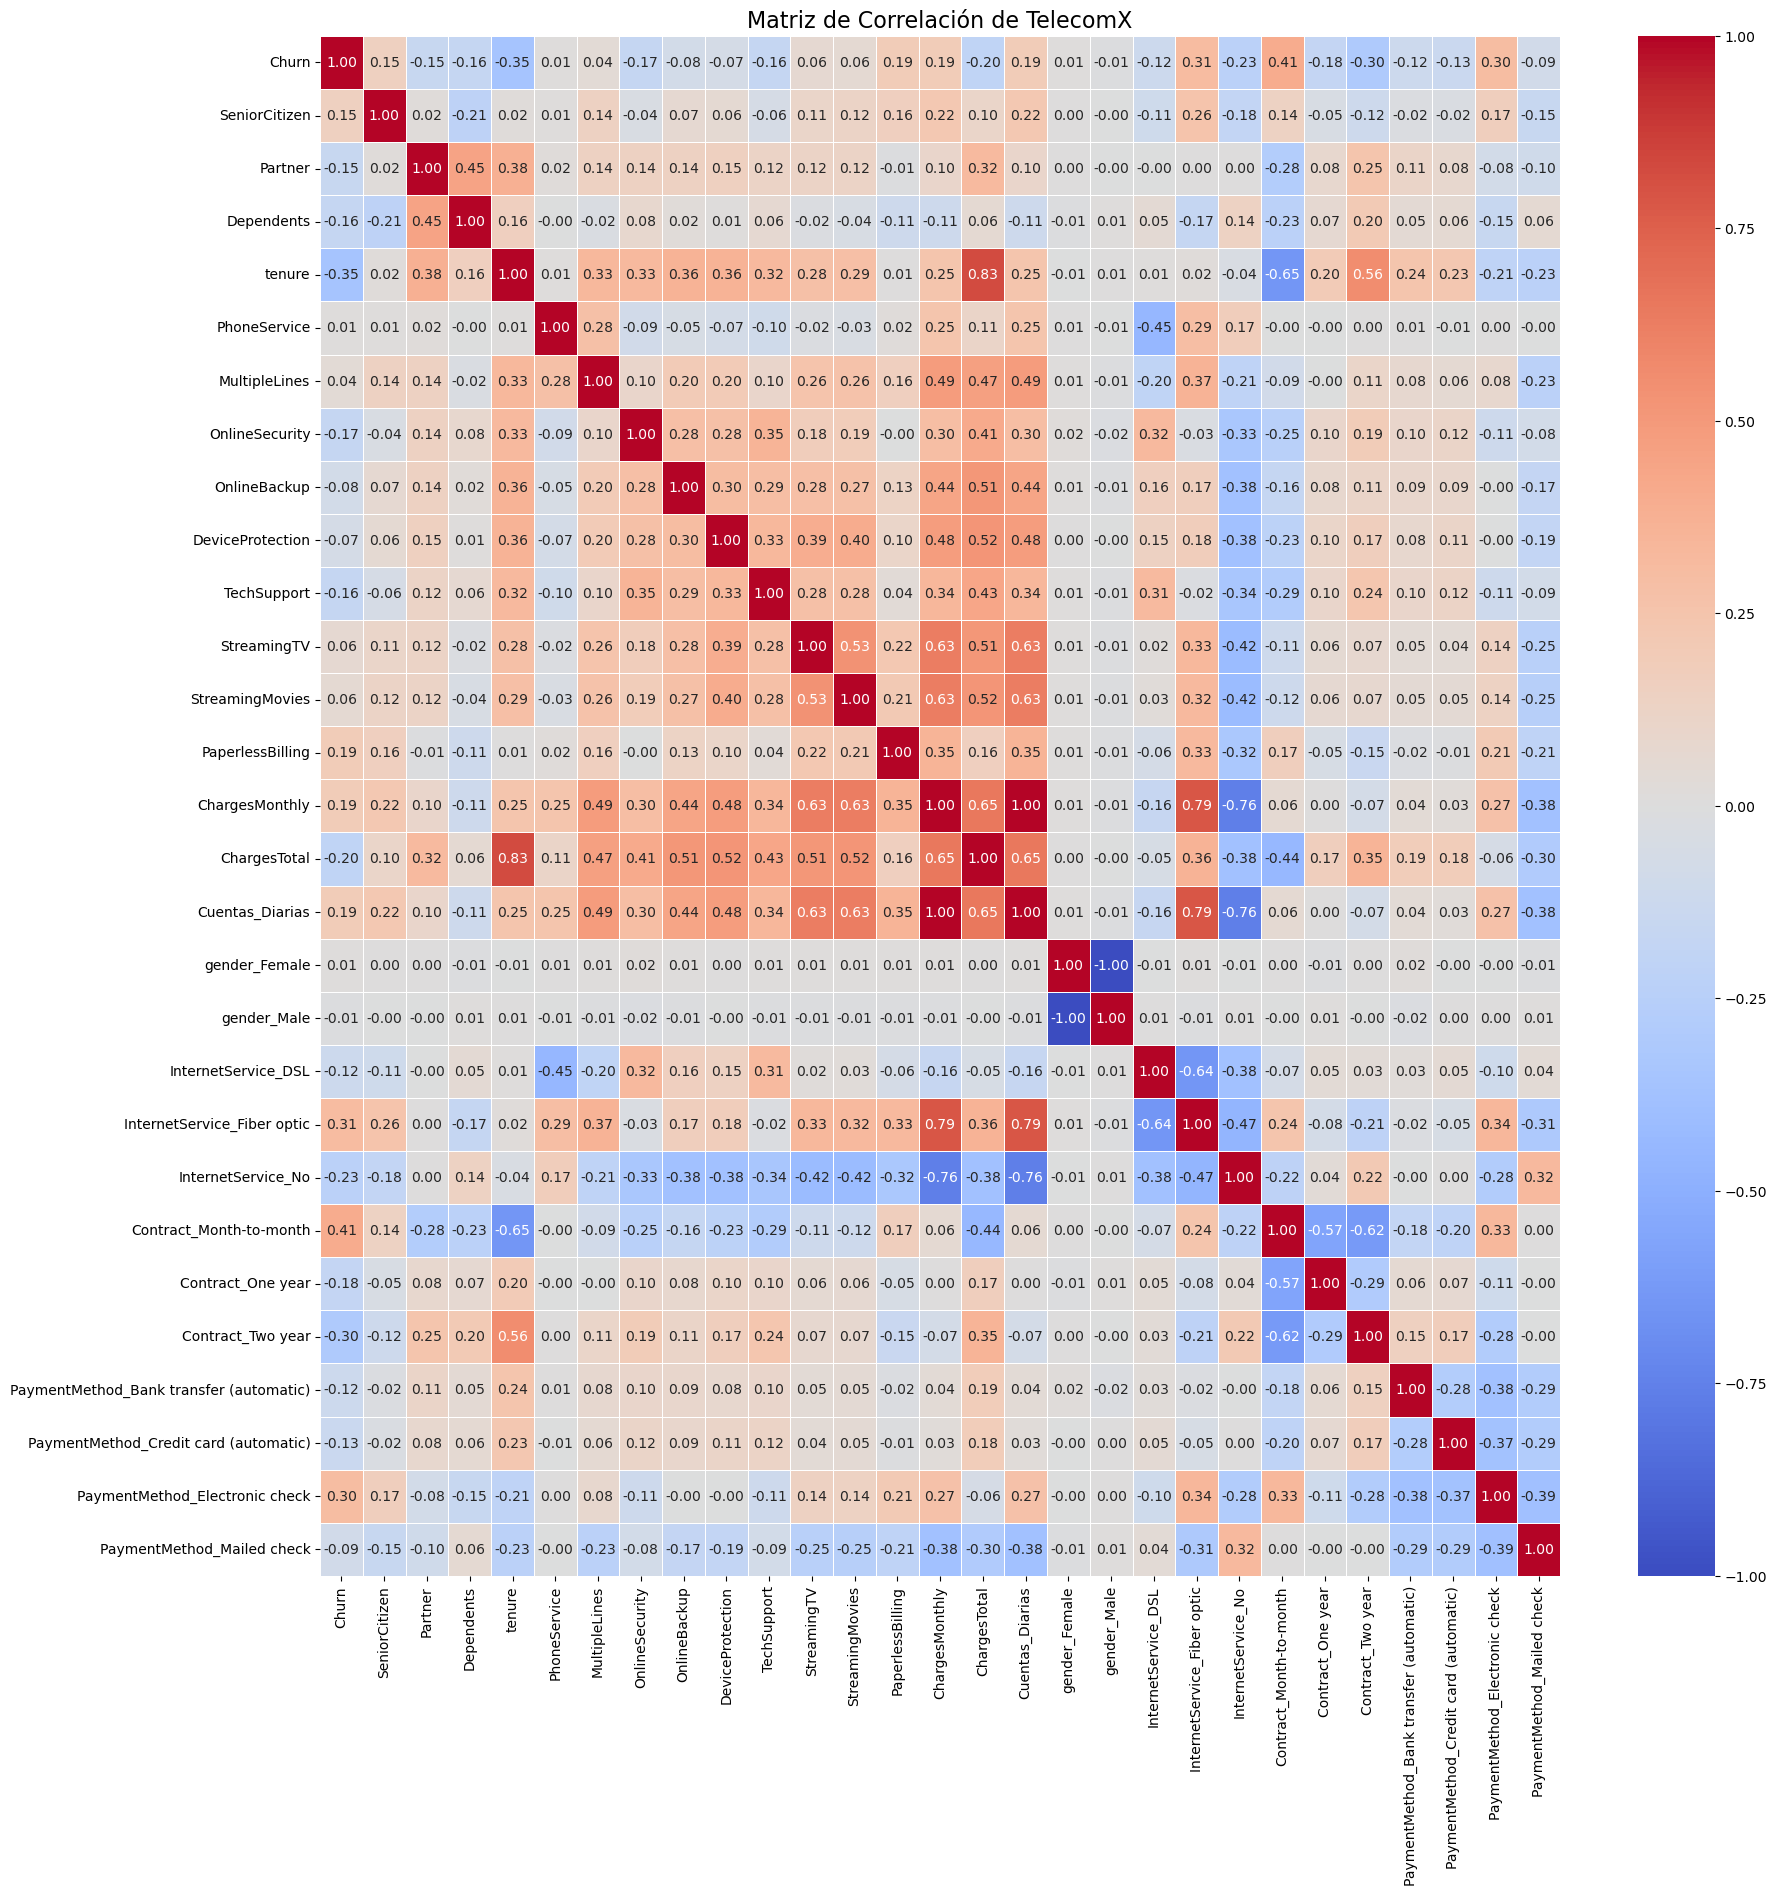

In [14]:
plt.figure(figsize=(20,20))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de TelecomX', fontsize=16)
plt.show()

In [15]:
# Ordenamos de mayor a menor para que el gráfico sea legible y dejaamos solo la correlacion con Churn.
churn_corr = matriz_correlacion['Churn'].sort_values(ascending=False).drop('Churn').reset_index()
# Renombramos las columnas
churn_corr.columns = ['Variables', 'Correlacion']
churn_corr.sample(5)

,Variables,Correlacion
9,MultipleLines,0.040102
23,Contract_One year,-0.177820
15,PaymentMethod_Mailed check,-0.091683
14,OnlineBackup,-0.082255
5,PaperlessBilling,0.191825


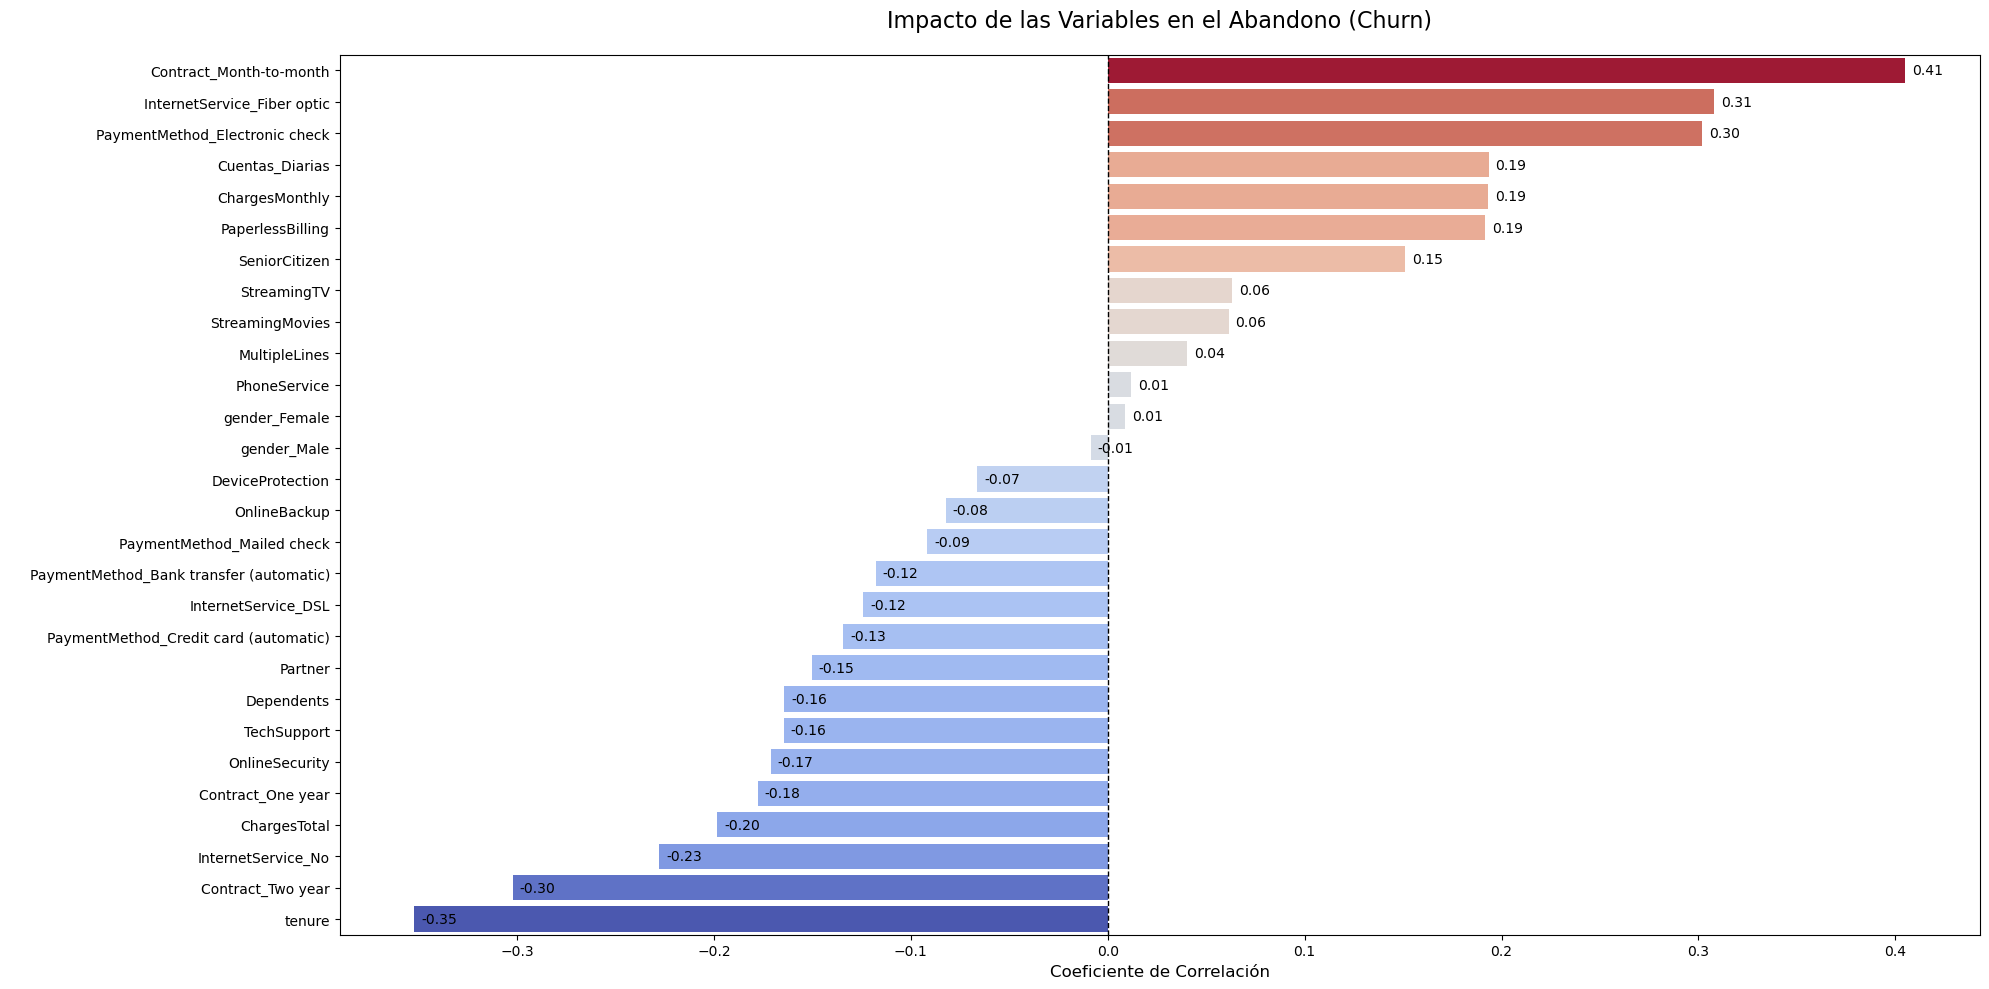

In [16]:
plt.figure(figsize=(20,10))

ax = sns.barplot(
    data=churn_corr, 
    x='Correlacion', 
    y='Variables', 
    hue='Correlacion', 
    palette='coolwarm',
    legend=False
)

plt.title('Impacto de las Variables en el Abandono (Churn)', fontsize=16, pad=20)
plt.xlabel('Coeficiente de Correlación', fontsize=12)
plt.ylabel(' ')

# Añadimos una línea vertical en 0 para separar claramente los bandos
plt.axvline(0, color='black', lw=1, ls='--')

# Añadimos el valor numérico al final de cada barra
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

## 🎯 Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

* Tiempo de contrato × Cancelación.
* Gasto total × Cancelación.

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [17]:
df_encoded.sample(10)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,ChargesMonthly,ChargesTotal,Cuentas_Diarias,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5567,True,False,False,False,2,True,False,False,False,False,False,False,False,True,46.00,84.50,1.53,False,True,True,False,False,True,False,False,False,True,False,False
131,True,False,False,False,5,True,True,False,False,False,False,False,False,False,47.15,223.15,1.57,False,True,True,False,False,True,False,False,False,False,True,False
271,True,False,False,False,37,True,True,False,True,True,False,True,True,True,101.90,3545.35,3.40,True,False,False,True,False,True,False,False,True,False,False,False
464,True,True,True,True,1,True,False,False,False,False,False,False,False,True,69.25,69.25,2.31,True,False,False,True,False,True,False,False,False,False,True,False
1927,False,False,False,False,24,True,False,True,False,False,True,False,False,False,54.95,1348.50,1.83,False,True,True,False,False,True,False,False,False,False,True,False
3845,False,True,True,False,65,True,False,False,False,False,False,False,False,True,70.95,4555.20,2.37,False,True,False,True,False,False,True,False,True,False,False,False
6764,False,True,False,False,1,True,False,False,False,False,False,False,False,True,70.05,70.05,2.34,False,True,False,True,False,True,False,False,False,False,True,False
6531,True,True,True,False,4,True,True,False,False,False,False,False,False,False,74.95,308.70,2.50,False,True,False,True,False,True,False,False,False,False,True,False
5356,False,False,True,True,72,True,True,True,False,False,False,False,False,False,79.05,5730.70,2.64,True,False,False,True,False,False,False,True,True,False,False,False
6594,False,False,True,True,52,True,False,False,False,False,False,False,False,False,19.85,1070.50,0.66,True,False,False,False,True,False,False,True,False,False,False,True


In [18]:
si_cancelaron = df_encoded[df_encoded['Churn'] == True]
no_cancelaron = df_encoded[df_encoded['Churn'] == False]

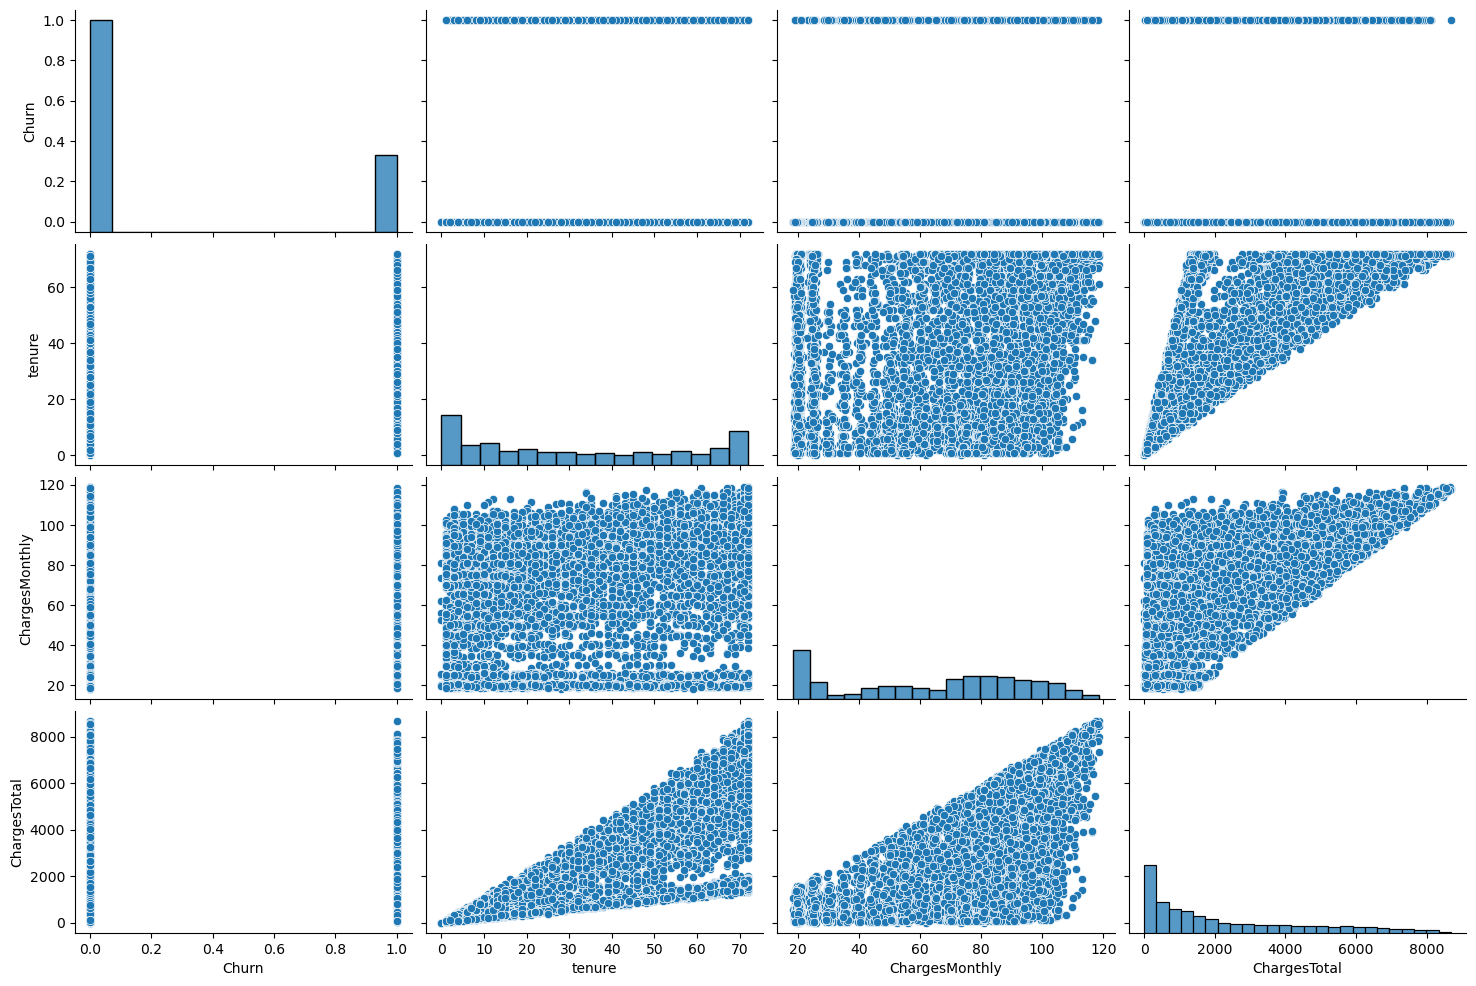

In [19]:
sns.pairplot(df_encoded, x_vars=['Churn', 'tenure', 'ChargesMonthly', 'ChargesTotal'], y_vars=['Churn', 'tenure', 'ChargesMonthly', 'ChargesTotal'], height=2.5, aspect=1.5)
plt.show()

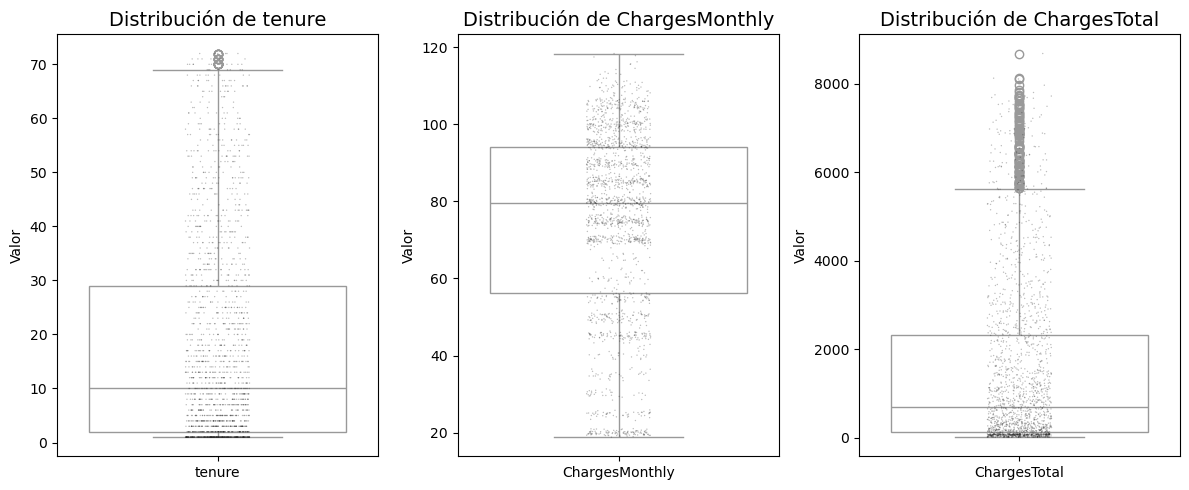

In [20]:
analizys_boxplot = ['tenure', 'ChargesMonthly', 'ChargesTotal']

fig, ax = plt.subplots(1, 3, figsize=(12, 5))
for i, col in enumerate(analizys_boxplot):
    # Usamos x=[""] * len(churn_false) para crear una base común
    # Y asignamos un nombre fijo al hue para que no se pierda en valores individuales
    sns.boxplot(
        data=si_cancelaron, 
        y=col, 
        x=[col] * len(si_cancelaron), # Esto crea una etiqueta única en el eje X
        hue=[col] * len(si_cancelaron), # Esto asigna un color único a esa etiqueta
        ax=ax[i], 
        palette='dark:white_r', 
        legend=False
    )

    # Encima dibujamos el Stripplot (los puntos individuales)
    sns.stripplot(
        data=si_cancelaron, 
        y=col, 
        ax=ax[i], 
        x=[col] * len(si_cancelaron),
        hue=[col] * len(si_cancelaron),
        size=1,        # Puntos muy pequeños
        jitter=True,   # Dispersión horizontal
        alpha=0.3,     # Transparencia
        palette='dark:black',
    )
    
    ax[i].set_title(f'Distribución de {col}', fontsize=14)
    ax[i].set_xlabel('') # Limpiamos el eje X para que no se vea repetido
    ax[i].set_ylabel('Valor')
plt.tight_layout()
plt.show()

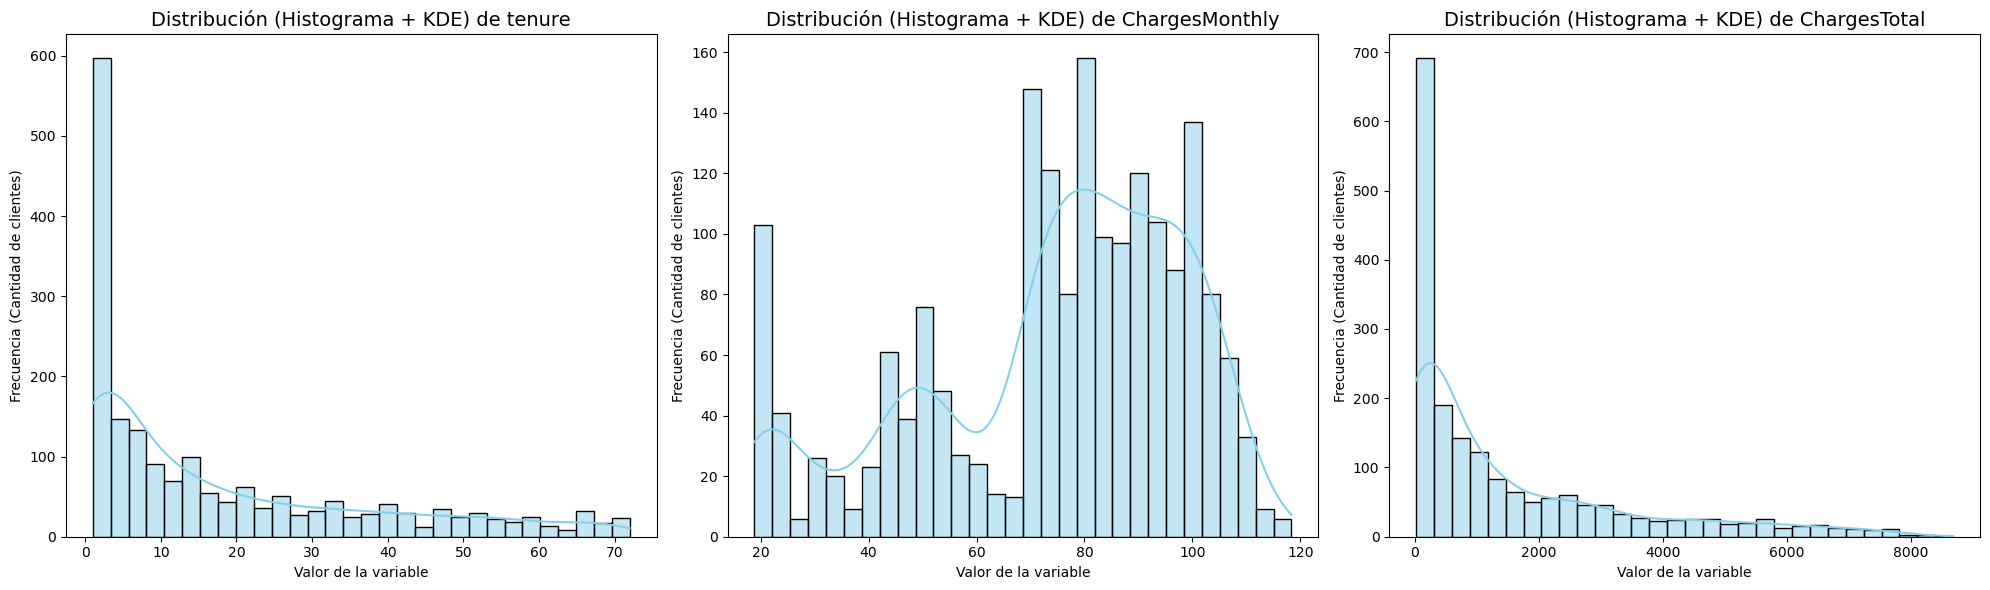

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(analizys_boxplot):
    # Usamos histplot con KDE para ver la "montaña" de densidad
    sns.histplot(data=si_cancelaron, x=col, kde=True, ax=axes[i], color='skyblue', bins=30)
    
    axes[i].set_title(f'Distribución (Histograma + KDE) de {col}', fontsize=14)
    axes[i].set_ylabel('Frecuencia (Cantidad de clientes)')
    axes[i].set_xlabel('Valor de la variable')

plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

## 🤖 Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
datos = pd.read_csv('TelecomX_Data_encoded.csv')
datos.sample(5)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,ChargesMonthly,ChargesTotal,Cuentas_Diarias,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6135,False,False,True,True,68,True,True,True,True,True,True,True,True,False,88.00,6161.90,2.93,True,False,True,False,False,False,False,True,False,True,False,False
4287,False,False,False,False,54,True,True,False,True,False,False,True,True,True,97.20,5129.45,3.24,True,False,False,True,False,False,False,True,True,False,False,False
3466,True,False,False,True,31,True,True,False,False,False,False,True,False,True,86.55,2697.40,2.88,True,False,False,True,False,True,False,False,False,True,False,False
6659,True,False,False,False,15,True,False,False,False,True,False,False,True,True,59.45,892.65,1.98,True,False,True,False,False,True,False,False,False,False,True,False
5607,False,False,False,False,25,False,False,False,False,True,False,True,True,True,48.25,1293.80,1.61,True,False,True,False,False,True,False,False,False,False,True,False


In [24]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']


# Split de los datos 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (4930, 28)
X_test shape: (2113, 28)
y_train shape: (4930,)
y_test shape: (2113,)


### 🛠️ Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

In [25]:
print(datos['Churn'].value_counts())

# Porcentajes de falsos y porcentaje de Trues
print(datos['Churn'].value_counts(normalize=True)*100)

Churn
False    5174
True     1869
Name: count, dtype: int64
Churn
False    73.463013
True     26.536987
Name: proportion, dtype: float64


### 🛠️ Opcionales no opcionales

#### Normalización o Estandarización (si es necesario)

In [26]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'ChargesMonthly', 'ChargesTotal', 'Cuentas_Diarias']

scaler = StandardScaler()

# Creamos copias para no dañar los originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Normalizamos SOLO las numéricas
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [27]:
X_train_scaled.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,ChargesMonthly,ChargesTotal,Cuentas_Diarias,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
302,False,True,False,0.629200,True,False,False,False,False,False,False,False,True,-1.495350,-0.556195,-1.493512,False,True,False,False,True,False,False,True,False,False,False,True
803,False,True,False,0.588538,True,True,False,False,False,False,False,False,False,-1.317809,-0.511030,-1.314330,False,True,False,False,True,True,False,False,False,False,True,False
3045,True,False,False,0.181910,False,False,False,True,True,False,False,False,False,-0.944475,-0.434091,-0.946012,False,True,True,False,False,True,False,False,False,False,True,False
722,False,True,True,-1.281949,True,False,False,False,False,False,False,False,False,-1.501987,-1.000909,-1.503466,False,True,False,False,True,False,True,False,False,True,False,False
1423,False,True,True,-0.672008,True,False,False,False,False,False,False,False,False,-1.518579,-0.888850,-1.523376,True,False,False,False,True,True,False,False,False,False,False,True


#### Balanceo de Clases despues de Normalizado (opcional)

In [28]:
from imblearn.over_sampling import SMOTE

smote_balanced = SMOTE(random_state=42)
X_train_res, y_train_res = smote_balanced.fit_resample(X_train_scaled, y_train)

print(f'X_train_res shape: {X_train_res.shape}')
print(f'y_train_res shape: {y_train_res.shape}')

X_train_res shape: (7244, 28)
y_train_res shape: (7244,)


## 🤖 Creación de Modelos

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate

### 🤖 LogisticRegression (Con datos Normalizados y Balanceados)

In [30]:
from sklearn.linear_model import LogisticRegression

# Instanciamos el modelo
# Usamos 'max_iter' un poco más alto para asegurar que el algoritmo converja
model_LogisticRegression = LogisticRegression(random_state=42, max_iter=1000)
# Entrenamos con los datos balanceados (SMOTE + Scaled)
model_LogisticRegression.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 🤖 KNeighborsClassifier (Con datos Normalizados y Balanceados)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

#Definimos el modelo
# n_neighbors=5 es el estándar, pero puedes probar con 3, 7 o 9.
model_KNeighborsClassifier = KNeighborsClassifier(n_neighbors=9, weights='distance')
# Entrenamos con los datos que ya escalamos y balanceamos con SMOTE
model_KNeighborsClassifier.fit(X_train_res, y_train_res)

,n_neighbors,9
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 🤖 SVM (Support Vector Machine) (Con datos Normalizados SIN Balanceo)

In [32]:
from sklearn.svm import SVC

# Definimos el modelo
model_SVC = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
# Entrenamos con los datos que ya escalamos
model_SVC.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


### 🤖 RandomForestClassifier (Sin datos Normalizados pero SI Balanceados)

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamos
model_RandomForestClassifier = RandomForestClassifier(n_estimators=100, random_state=42)
model_RandomForestClassifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 🤖 Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

* Exactitud (Acurácia)
* Precisión
* Recall
* F1-score
* Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

* ¿Cuál modelo tuvo el mejor desempeño?
* ¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:
    * Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.
    * Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

### 🤖 Evaluacion LogisticRegression (Con datos Normalizados y Balanceados)

In [34]:
# Predecimos usando el set de TEST (el que no tiene SMOTE)
y_pred_LogisticRegression = model_LogisticRegression.predict(X_test_scaled)

# Obtenemos las probabilidades (esto es único de la Logística)
# Esto nos da la probabilidad de ser 'True' (clase 1)
y_prob_LogisticRegression = model_LogisticRegression.predict_proba(X_test_scaled)[:, 1]

# Evaluamos
print("--- Reporte de Regresión Logística ---")
# El reporte usa las predicciones (y_pred)
print(classification_report(y_test, y_pred_LogisticRegression))

# El ROC-AUC usa las probabilidades (y_prob)
score_auc = roc_auc_score(y_test, y_prob_LogisticRegression)
print(f"ROC-AUC Score: {score_auc:.2f} \n")
# Confusion Matrix
print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred_LogisticRegression)}')

--- Reporte de Regresión Logística ---
              precision    recall  f1-score   support

       False       0.88      0.78      0.83      1552
        True       0.54      0.71      0.62       561

    accuracy                           0.76      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.79      0.76      0.77      2113

ROC-AUC Score: 0.83 

Confusion matrix:
[[1216  336]
 [ 162  399]]


In [35]:
# 1. Calculamos el score para el set de entrenamiento
train_score = model_LogisticRegression.score(X_train, y_train)

# 2. Calculamos el score para el set de prueba
test_score = model_LogisticRegression.score(X_test, y_test)

print(f"Accuracy en Entrenamiento: {train_score:.4f}")
print(f"Accuracy en Prueba: {test_score:.4f}")

# 3. Diferencia
print(f"Diferencia (Gap): {train_score - test_score:.4f}")

Accuracy en Entrenamiento: 0.2471
Accuracy en Prueba: 0.2560
Diferencia (Gap): -0.0090


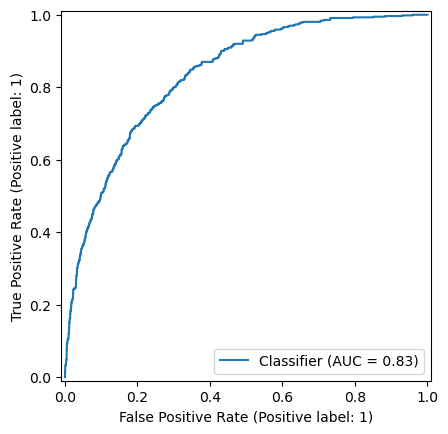

In [36]:
RocCurveDisplay.from_predictions(y_test, y_prob_LogisticRegression);

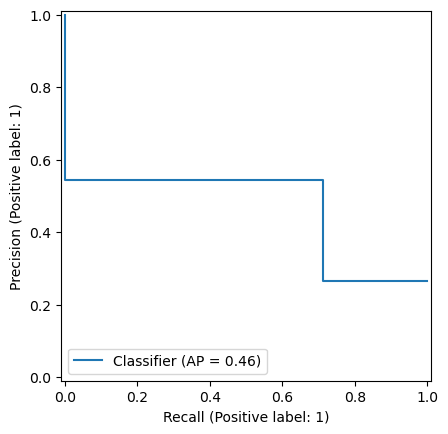

In [37]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred_LogisticRegression);

### 🤖 Evaluacion KNeighborsClassifier (Con datos Normalizados y Balanceados)

In [38]:
# Predecimos sobre el set de test (que ya debe estar escalado)
y_pred_model_KNeighborsClassifier = model_KNeighborsClassifier.predict(X_test_scaled)

# Evaluamos
print("--- Reporte de Clasificación KNN ---")
print(classification_report(y_test, y_pred_model_KNeighborsClassifier))
print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred_model_KNeighborsClassifier)}')

--- Reporte de Clasificación KNN ---
              precision    recall  f1-score   support

       False       0.87      0.72      0.79      1552
        True       0.47      0.69      0.56       561

    accuracy                           0.71      2113
   macro avg       0.67      0.71      0.67      2113
weighted avg       0.76      0.71      0.73      2113

Confusion matrix:
[[1120  432]
 [ 174  387]]


In [39]:
# Calculamos el score para el set de entrenamiento
train_score = model_KNeighborsClassifier.score(X_train_res, y_train_res)

# Calculamos el score para el set de prueba
test_score = model_KNeighborsClassifier.score(X_test, y_test)

print(f"Accuracy en Entrenamiento: {train_score:.4f}")
print(f"Accuracy en Prueba: {test_score:.4f}")

# Diferencia
print(f"Diferencia (Gap): {train_score - test_score:.4f}")

Accuracy en Entrenamiento: 0.9985
Accuracy en Prueba: 0.7345
Diferencia (Gap): 0.2640


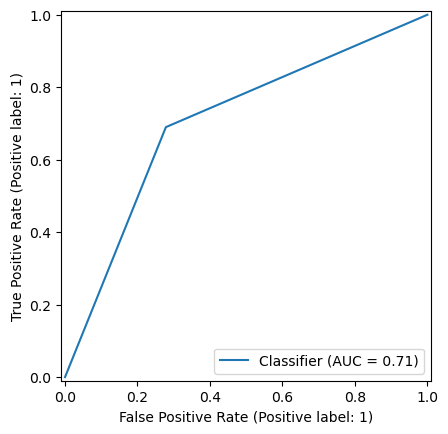

In [40]:
RocCurveDisplay.from_predictions(y_test, y_pred_model_KNeighborsClassifier);

In [41]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados = cross_validate(model_KNeighborsClassifier, X_train, y_train, cv=skf, scoring='recall')
print(resultados['test_score'].mean())

0.43960657662947744


### 🤖 Evaluacion RandomForestClassifier (Sin datos Normalizados pero SI Balanceados)

In [42]:
# Predecimos
y_pred_RandomForestClassifier = model_RandomForestClassifier.predict(X_test)

# Evaluamos
print("--- Reporte de Clasificación Random Forest ---")
print(classification_report(y_test, y_pred_RandomForestClassifier))
print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred_RandomForestClassifier)}')

--- Reporte de Clasificación Random Forest ---
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1552
        True       0.62      0.50      0.55       561

    accuracy                           0.79      2113
   macro avg       0.72      0.70      0.71      2113
weighted avg       0.77      0.79      0.78      2113

Confusion matrix:
[[1376  176]
 [ 278  283]]


In [43]:
# Calculamos el score para el set de entrenamiento
train_score = model_RandomForestClassifier.score(X_train, y_train)

# Calculamos el score para el set de prueba
test_score = model_RandomForestClassifier.score(X_test, y_test)

print(f"Accuracy en Entrenamiento: {train_score:.4f}")
print(f"Accuracy en Prueba: {test_score:.4f}")

# Diferencia
print(f"Diferencia (Gap): {train_score - test_score:.4f}")

Accuracy en Entrenamiento: 0.9978
Accuracy en Prueba: 0.7851
Diferencia (Gap): 0.2126


#### RandomForestClassifier ha generado Overfitting

In [44]:
# Re-entrenamos con límites (Podar del árbol)
model_RandomForestClassifier_fixed = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,                # No dejamos que el árbol crezca infinito
    min_samples_leaf=20,        # Cada "hoja" debe tener al menos 20 clientes
    max_features='sqrt',        # Solo mira algunas variables a la vez
    class_weight='balanced',
    random_state= 32
)

# Entrenar de nuevo con los datos de SMOTE (X_train_res)
model_RandomForestClassifier_fixed.fit(X_train, y_train)

# Volver a revisar los scores
train_score_fixed = model_RandomForestClassifier_fixed.score(X_train, y_train)
test_score_fixed = model_RandomForestClassifier_fixed.score(X_test, y_test)

print(f"Nuevo Accuracy Train: {train_score_fixed:.4f}")
print(f"Nuevo Accuracy Test: {test_score_fixed:.4f}")
print(f"Nuevo Gap: {train_score_fixed - test_score_fixed:.4f}")

Nuevo Accuracy Train: 0.7580
Nuevo Accuracy Test: 0.7411
Nuevo Gap: 0.0169


In [45]:
y_pred_final = model_RandomForestClassifier_fixed.predict(X_test)
print(classification_report(y_test, y_pred_final))
print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred_RandomForestClassifier)}')

              precision    recall  f1-score   support

       False       0.91      0.72      0.80      1552
        True       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113

Confusion matrix:
[[1376  176]
 [ 278  283]]


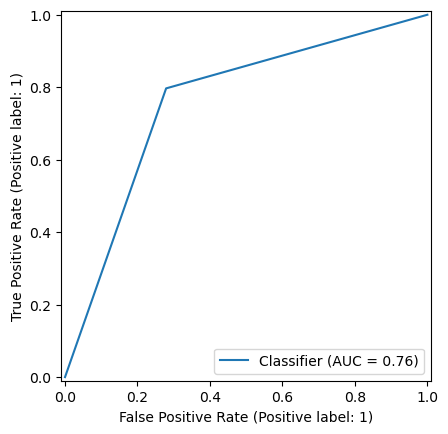

In [46]:
# Obtenemos las probabilidades (esto es único de la Logística)
RocCurveDisplay.from_predictions(y_test, y_pred_final);  # Esto nos da la probabili

### 🤖 Evaluacion SVM (Support Vector Machine) (Con datos Normalizados SIN Balanceo)

In [47]:
# Predecimos sobre el set de test ESCALADO
y_pred_model_SVC = model_SVC.predict(X_test_scaled)

# Evaluamos
print(classification_report(y_test, y_pred_model_SVC))
print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred_model_SVC)}')

              precision    recall  f1-score   support

       False       0.91      0.64      0.75      1552
        True       0.46      0.83      0.59       561

    accuracy                           0.69      2113
   macro avg       0.68      0.74      0.67      2113
weighted avg       0.79      0.69      0.71      2113

Confusion matrix:
[[996 556]
 [ 96 465]]


In [48]:
# 1. Calculamos el score para el set de entrenamiento
train_score = model_SVC.score(X_train_scaled, y_train)

# 2. Calculamos el score para el set de prueba
test_score = model_SVC.score(X_test, y_test)

print(f"Accuracy en Entrenamiento: {train_score:.4f}")
print(f"Accuracy en Prueba: {test_score:.4f}")

# 3. Diferencia
print(f"Diferencia (Gap): {train_score - test_score:.4f}")

Accuracy en Entrenamiento: 0.7047
Accuracy en Prueba: 0.7104
Diferencia (Gap): -0.0057


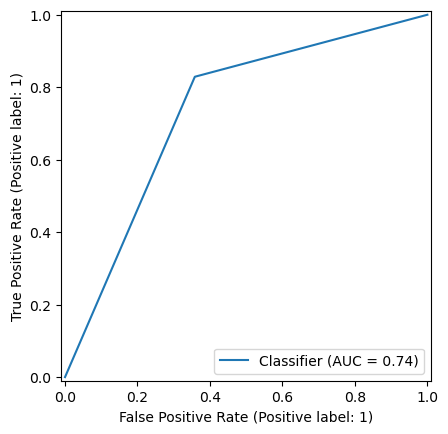

In [49]:
RocCurveDisplay.from_predictions(y_test, y_pred_model_SVC);  # Esto nos da la probabilidad

# 📋 Interpretación y Conclusiones

## 📋 Análisis de la Importancia de las Variables

#### Análisis de la Importancia de las Variables (LogisticRegression)

In [50]:
importances_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_LogisticRegression.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print(importances_log)

                                   Variable  Coeficiente
19              InternetService_Fiber optic     6.582496
4                              PhoneService     3.996666
21                  Contract_Month-to-month     3.830562
26           PaymentMethod_Electronic check     3.319740
22                        Contract_One year     3.006627
27               PaymentMethod_Mailed check     2.909985
24  PaymentMethod_Bank transfer (automatic)     2.798768
25    PaymentMethod_Credit card (automatic)     2.687205
16                            gender_Female     2.521685
17                              gender_Male     2.469212
11                          StreamingMovies     2.351467
10                              StreamingTV     2.346300
23                        Contract_Two year     2.192027
5                             MultipleLines     1.495886
8                          DeviceProtection     1.208071
14                             ChargesTotal     1.131786
7                              

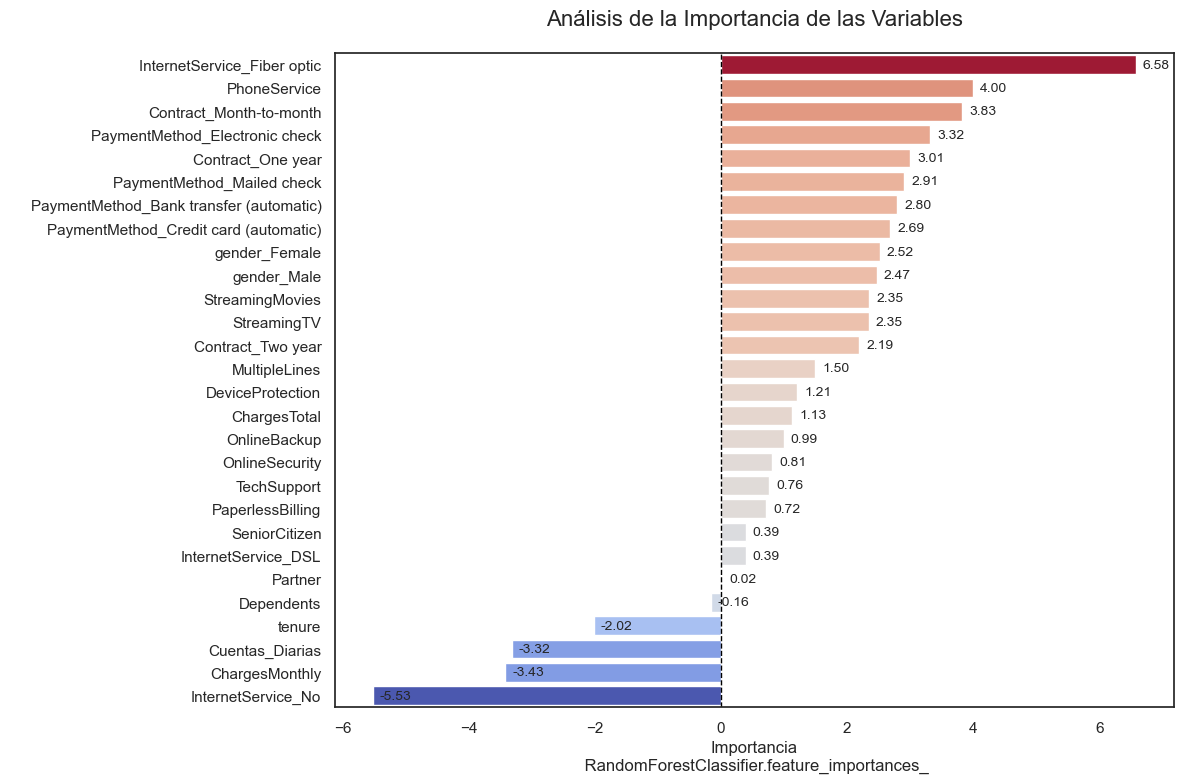

In [51]:
sns.set_theme(style='white')

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=importances_log, 
    x='Coeficiente', 
    y='Variable', 
    hue='Coeficiente', 
    palette='coolwarm',
    legend=False
)

plt.title('Análisis de la Importancia de las Variables', fontsize=16, pad=20)
plt.xlabel('Importancia\n RandomForestClassifier.feature_importances_', fontsize=12)
plt.ylabel(' ')

# Añadimos una línea vertical en 0 para separar claramente los bandos
plt.axvline(0, color='black', lw=1, ls='--')

# Añadimos el valor numérico al final de cada barra
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

#### Análisis de la Importancia de las Variables (RandomForestClassifier)

In [52]:
# Usando tu modelo 'model_RandomForestClassifier_fixed'
importances_rf = model_RandomForestClassifier_fixed.feature_importances_
feature_names = X.columns
Variables_importantes_RF = pd.Series(importances_rf, index=feature_names).sort_values(ascending=False).reset_index()
Variables_importantes_RF.columns = ['Variables', 'Importancia']
print(Variables_importantes_RF)

                                  Variables  Importancia
0                   Contract_Month-to-month     0.207550
1                                    tenure     0.133061
2                         Contract_Two year     0.128858
3               InternetService_Fiber optic     0.098557
4                              ChargesTotal     0.092712
5            PaymentMethod_Electronic check     0.058581
6                            ChargesMonthly     0.052436
7                        InternetService_No     0.045063
8                         Contract_One year     0.043028
9                           Cuentas_Diarias     0.038937
10                              TechSupport     0.018913
11                      InternetService_DSL     0.014655
12                         PaperlessBilling     0.013946
13                           OnlineSecurity     0.011672
14                               Dependents     0.007184
15                            SeniorCitizen     0.006025
16                          Str

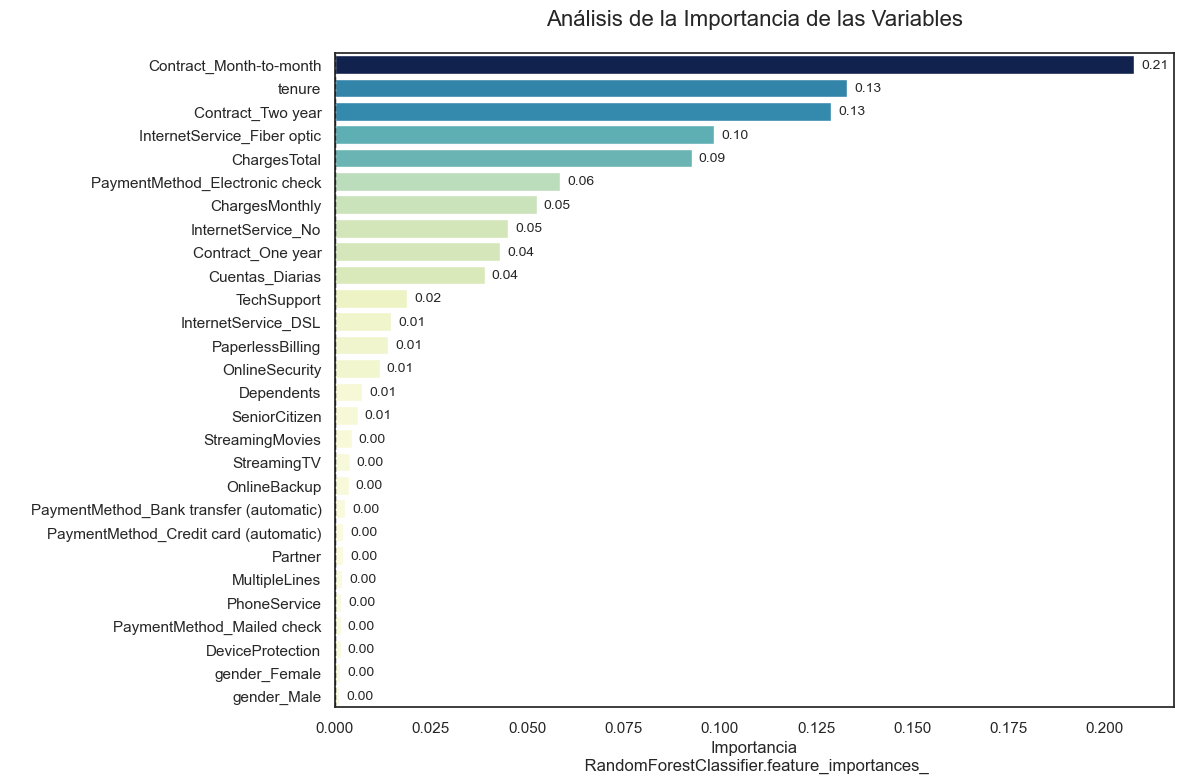

In [53]:
sns.set_theme(style='white')

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=Variables_importantes_RF, 
    x='Importancia', 
    y='Variables', 
    hue='Importancia', 
    palette='YlGnBu',
    legend=False
)

plt.title('Análisis de la Importancia de las Variables', fontsize=16, pad=20)
plt.xlabel('Importancia\n RandomForestClassifier.feature_importances_', fontsize=12)
plt.ylabel(' ')

# Añadimos una línea vertical en 0 para separar claramente los bandos
plt.axvline(0, color='black', lw=1, ls='--')

# Añadimos el valor numérico al final de cada barra
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

#### Análisis de la Importancia de las Variables (SVC)

In [54]:
# Solo funciona si kernel='linear'
coef_svm = pd.Series(model_SVC.coef_[0], index=X.columns).sort_values(ascending=False)
Variables_importantes_svm = coef_svm.reset_index()
Variables_importantes_svm.columns = ['Variables', 'Importancia']
print(Variables_importantes_svm)


                                  Variables  Importancia
0                   Contract_Month-to-month     1.333207
1               InternetService_Fiber optic     0.667673
2                       InternetService_DSL     0.666764
3                           Cuentas_Diarias     0.030529
4                              PhoneService     0.000963
5                               StreamingTV     0.000461
6                           StreamingMovies     0.000385
7                              ChargesTotal     0.000325
8                          DeviceProtection     0.000277
9                             MultipleLines     0.000176
10                           OnlineSecurity     0.000160
11                             OnlineBackup     0.000120
12                              TechSupport     0.000090
13                         PaperlessBilling     0.000071
14    PaymentMethod_Credit card (automatic)     0.000051
15                            gender_Female     0.000050
16                            S

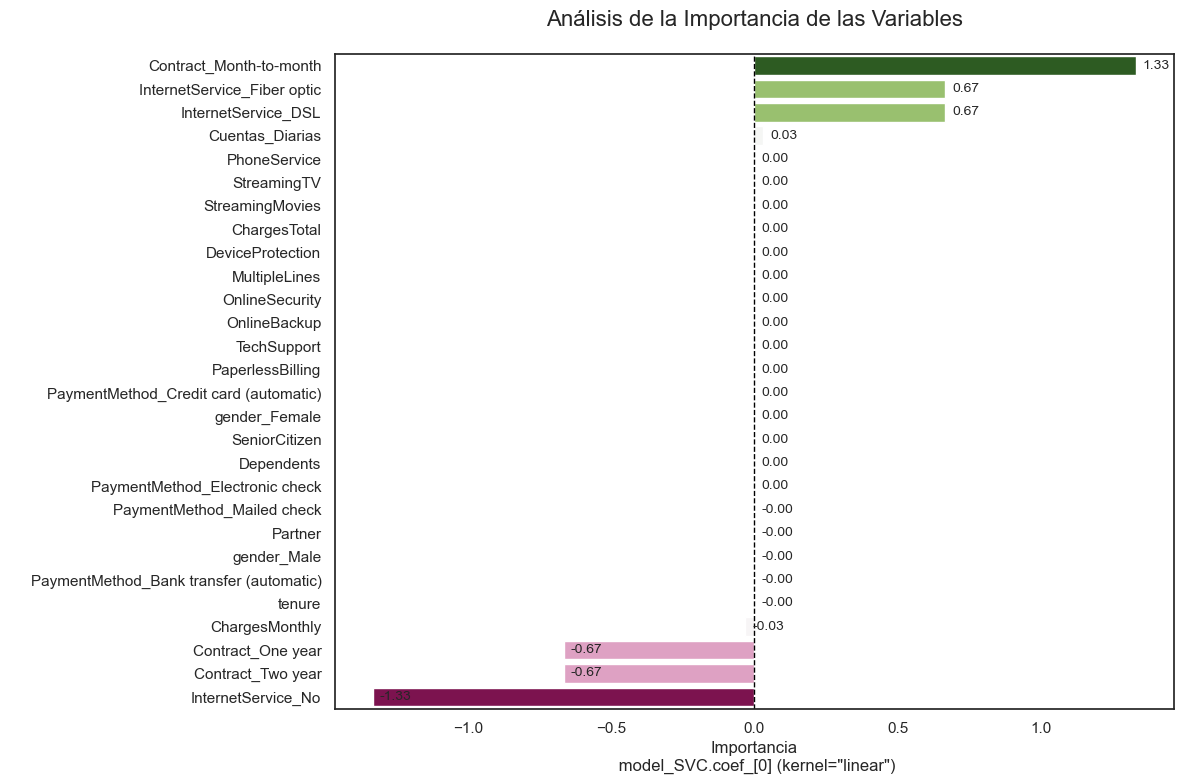

In [55]:
sns.set_theme(style='white')

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=Variables_importantes_svm, 
    x='Importancia', 
    y='Variables', 
    hue='Importancia', 
    palette='PiYG',
    legend=False
)

plt.title('Análisis de la Importancia de las Variables', fontsize=16, pad=20)
plt.xlabel('Importancia\n model_SVC.coef_[0] (kernel="linear")', fontsize=12)
plt.ylabel(' ')

# Añadimos una línea vertical en 0 para separar claramente los bandos
plt.axvline(0, color='black', lw=1, ls='--')

# Añadimos el valor numérico al final de cada barra
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

#### Análisis de la Importancia de las Variables (KNeighborsClassifier)

In [56]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Usamos el modelo KNN que se entreno con los datos escalados
results = permutation_importance(model_KNeighborsClassifier, X_test_scaled, y_test, scoring='accuracy', random_state=42)

# Graficamos
feature_importance = pd.Series(results.importances_mean, index=X.columns)
Variables_importantes_KNN = feature_importance.sort_values(ascending=False).reset_index()
Variables_importantes_KNN.columns = ['Variables', 'Importancia']
print(Variables_importantes_KNN)

                                  Variables  Importancia
0                                    tenure     0.008045
1                   Contract_Month-to-month     0.005774
2                              ChargesTotal     0.005206
3                            OnlineSecurity     0.004827
4                        InternetService_No     0.003975
5                            ChargesMonthly     0.003881
6            PaymentMethod_Electronic check     0.003691
7                           Cuentas_Diarias     0.003691
8                               TechSupport     0.003502
9                              PhoneService     0.002082
10                        Contract_Two year     0.000757
11                              StreamingTV     0.000000
12  PaymentMethod_Bank transfer (automatic)    -0.000095
13                              gender_Male    -0.000852
14    PaymentMethod_Credit card (automatic)    -0.000852
15                      InternetService_DSL    -0.000947
16                             

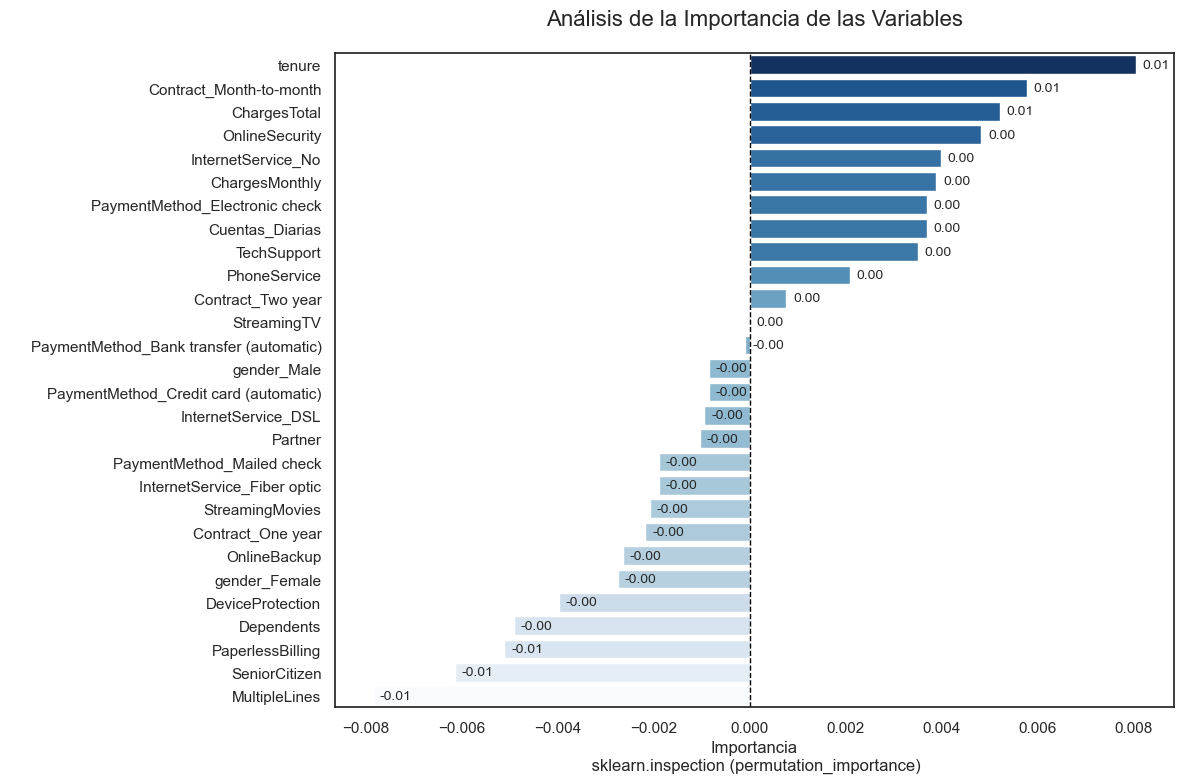

In [57]:
sns.set_theme(style='white')

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=Variables_importantes_KNN, 
    x='Importancia', 
    y='Variables', 
    hue='Importancia', 
    palette='Blues',
    legend=False
)

plt.title('Análisis de la Importancia de las Variables', fontsize=16, pad=20)
plt.xlabel('Importancia\n sklearn.inspection (permutation_importance)', fontsize=12)
plt.ylabel(' ')

# Añadimos una línea vertical en 0 para separar claramente los bandos
plt.axvline(0, color='black', lw=1, ls='--')

# Añadimos el valor numérico al final de cada barra
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

## 📋 Conclusión